# Pruebas de Analítica sobre base de datos Resultados agregados ICFES **Saber PRO 2019-2025**
Consultas de prueba de la base de datos consolidada de **_saberpro_star_schema.db_**

In [1]:
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np
import re
import os
import sqlite3

print('\nLibrerías necesarias importadas!\nSe puede proceder con las consultas')


Librerías necesarias importadas!
Se puede proceder con las consultas


# Análsis generales
Las siguientes consultas se enfocan en los resultados más relevantes de las pruebas Saber PRO 2019-2025 a nivel general.
Indagan las dimensiones más generales de cobertura histórica, impacto institucional y rendimiento de la población estudiantil.

    ANIO                 PRUEBA_NBC  TOTAL_EVALUADOS
30  2025    COMPETENCIAS CIUDADANAS           283842
31  2025       COMUNICACIÓN ESCRITA           283841
32  2025                     INGLÉS           283842
33  2025            LECTURA CRÍTICA           283842
34  2025  RAZONAMIENTO CUANTITATIVO           283842


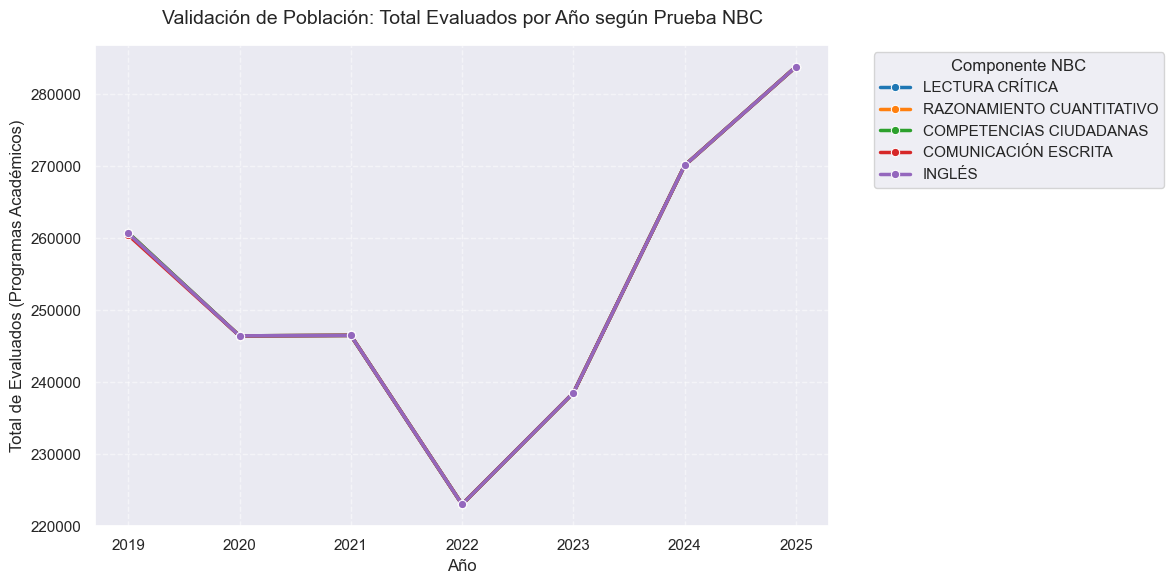

In [54]:
# 1. Consulta 1: Total evaluados por NBC - pruebas globales
conn = sqlite3.connect('saberpro_star_schema.db')

# 2. Consulta SQL
query_validacion = """
    SELECT 
        t.ANIO,
        p.NOMBRE_PRUEBA AS PRUEBA_NBC,
        SUM(f.CANTIDADEVALUADOS) AS TOTAL_EVALUADOS
    FROM FACT_RESULTADOS f
    JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
    JOIN DIM_PRUEBA p ON f.id_prueba = p.id_prueba
    WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
      AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
      AND p.NOMBRE_PRUEBA IN (
          'COMPETENCIAS CIUDADANAS', 
          'COMUNICACIÓN ESCRITA', 
          'LECTURA CRÍTICA', 
          'RAZONAMIENTO CUANTITATIVO', 
          'INGLÉS'
      )
    GROUP BY t.ANIO, p.NOMBRE_PRUEBA
    ORDER BY t.ANIO, p.NOMBRE_PRUEBA;
"""

df_validacion = pd.read_sql(query_validacion, conn)
conn.close()
print(df_validacion.tail(5))

# 3. Visualización: leyenda forzada
orden_pruebas = [
    'LECTURA CRÍTICA', 
    'RAZONAMIENTO CUANTITATIVO', 
    'COMPETENCIAS CIUDADANAS', 
    'COMUNICACIÓN ESCRITA', 
    'INGLÉS'
]
df_validacion['PRUEBA_NBC'] = pd.Categorical(df_validacion['PRUEBA_NBC'], categories=orden_pruebas, ordered=True)

# 4. Visualización con Seaborn
plt.figure(figsize=(12, 6))

# 'hue' separa la línea por cada prueba automáticamente
sns.lineplot(
    data=df_validacion, 
    x='ANIO', 
    y='TOTAL_EVALUADOS', 
    hue='PRUEBA_NBC', 
    marker='o', 
    linewidth=2.5,
    palette='tab10' # Paleta de colores distinta y profesional
)

plt.title('Validación de Población: Total Evaluados por Año según Prueba NBC', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Evaluados (Programas Académicos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# leyenda fuera del gráfico para no tapar las líneas
plt.legend(title='Componente NBC', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Pruebas_saberpro_2019-2025_NBC.png', dpi=300)
plt.show()

En la gráfica anterior se evidencia que anualmente entre 220.000 y 270.000 estudiantes presentan las pruebas de nivel profesional, con tendencia descendente desde 2019, un punto mínimo en el año 2022 y un nuevo repunte, incluso superior al inicial para los años 2024 y 2025.</br>* Según el ICFES, en 2016, 2017 y 2018 se presentaron 242.629, 246.300 y 237.878 estudiantes respectivamente.</br>
**Tabla de comparación**: Resumen de resultados 2024-II</br>
| Año  | Oficial ICFES |   Pipeline  | Diferencia |   Mayor reporte  | Diferencia (%) |
| :--- | :------------ | :---------- | :--------- | :--------------- | :------------- |
| 2019 |    261,130    |   260,756   |    -374    |     **ICFES**    |      0.14      |
| 2020 |    247,442    |   246,437   |   -1,005   |     **ICFES**    |      0.41      |
| 2021 |    248,534    |   246,498   |   -2,036   |     **ICFES**    |      0.83      |
| 2022 |    222,960    |   223,011   |     +51    |   **Pipeline**   |     -0.02      |
| 2023 |    236,038    |   238,508   | **+2,470** |   **Pipeline**   |     -1.04      |
| 2024 |    268,562    |   270,125   |   +1,563   |   **Pipeline**   |     -0.58      |

</br>
Disponible en: https://www.icfes.gov.co/wp-content/uploads/2025/07/Resumen_Saber_Pro_Saber_TyT_2024-II.pdf

   ANIO                    programa  total_evaluados
0  2019  ADMINISTRACIÓN DE EMPRESAS            29501
1  2019          CONTADURÍA PÚBLICA            20223
2  2019                     DERECHO            19422
3  2019                  PSICOLOGÍA            18741
4  2019       INGENIERÍA INDUSTRIAL            12870


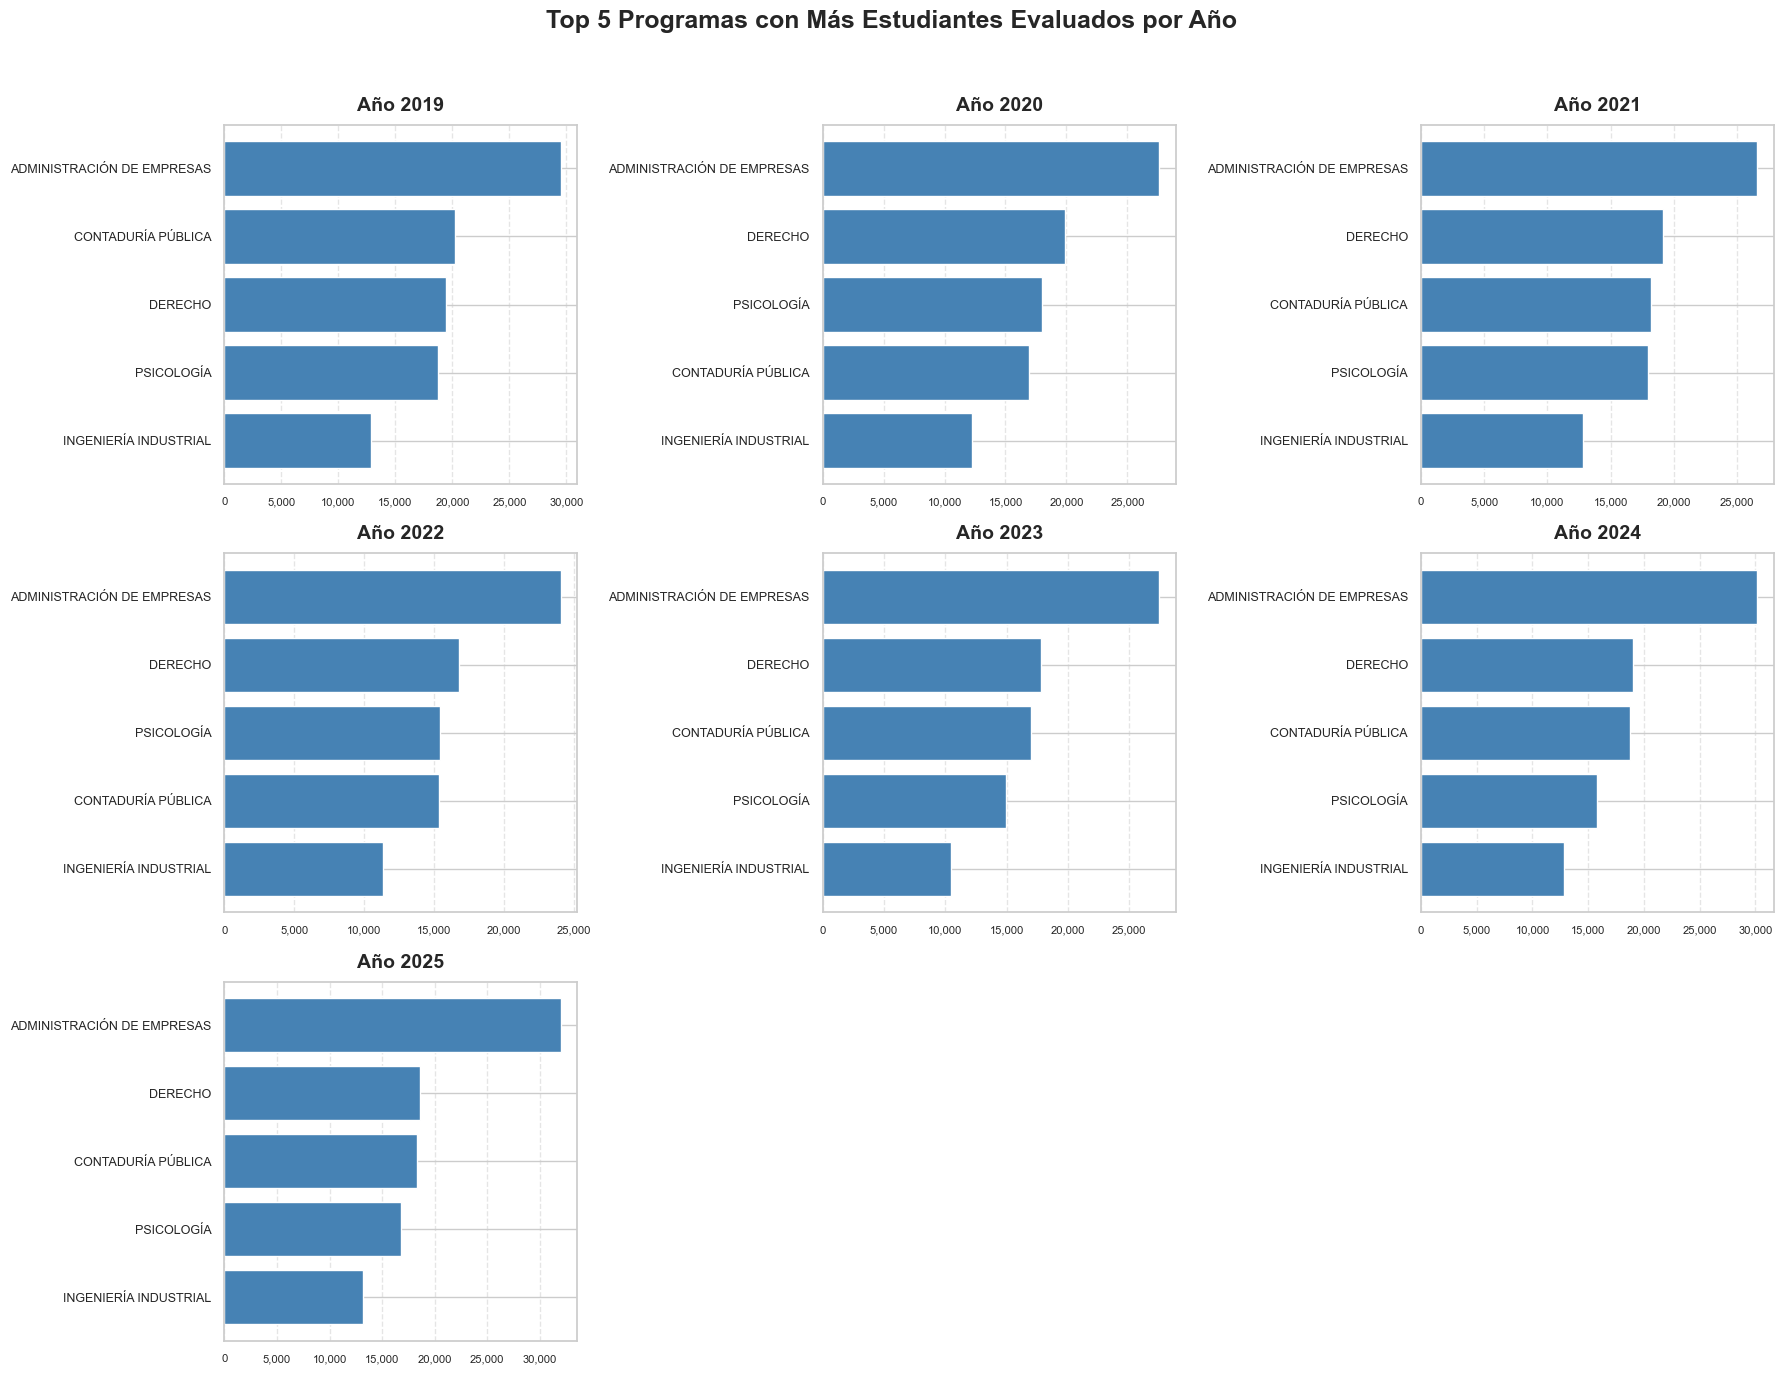

In [30]:
# =============================================================================
# 1. Consulta 2: Top 5 programas por cantidad de evaluados por año.
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
df_top5 = pd.read_sql("""
    WITH ranking AS (
        SELECT t.ANIO, p.nombre_programa_acad AS programa,
               SUM(f.CANTIDADEVALUADOS) AS total_evaluados,
               ROW_NUMBER() OVER (PARTITION BY t.anio ORDER BY SUM(f.CANTIDADEVALUADOS) DESC) AS rn
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_PROGRAMA p ON f.id_programa_acad = p.ID_PROGRAMA_ACAD
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'  
        AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
        AND q.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO' 
        AND f.id_programa_acad IS NOT NULL
        GROUP BY t.ANIO, p.nombre_programa_acad
    )
    SELECT ANIO, programa, total_evaluados
    FROM ranking WHERE rn <= 5
    ORDER BY ANIO, total_evaluados DESC;
""", conn)
conn.close()
print(df_top5.head(5))

# =============================================================================
# 2. CONFIGURACIÓN DINÁMICA DEL GRID
# =============================================================================
anios = sorted(df_top5['ANIO'].unique())
n_anios = len(anios)

# Definir la matriz: 3 columnas, y las filas necesarias (math.ceil redondea hacia arriba)
ncols = 3
nrows = math.ceil(n_anios / ncols) # 7 años / 3 columnas = 2.33 -> 3 filas

# Crear la figura con un tamaño adecuado (más ancha y alta)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14))
axes = axes.flatten() # Aplana la matriz de ejes para iterar fácilmente

# =============================================================================
# 3. DIBUJO DE GRÁFICOS
# =============================================================================
for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_top5[df_top5['ANIO'] == anio].sort_values('total_evaluados')
    
    # Dibujar barras horizontales
    ax.barh(df_anio['programa'], df_anio['total_evaluados'], color='steelblue', edgecolor='white')
    
    # Título del subgráfico
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold', pad=10)
    
    # Reducir tamaño de fuente del eje Y para evitar superposición
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    
    # Quitar etiquetas de los ejes para no saturar (el título da contexto)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Invertir el eje Y para que el #1 quede arriba
    #ax.invert_yaxis()
    
    # Añadir una cuadrícula sutil
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Formatear los números del eje X con separador de miles (ej: 40,000 en vez de 40000)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# =============================================================================
# 4. LIMPIEZA DE ESPACIOS VACÍOS Y AJUSTE FINAL
# =============================================================================
# Como 3x3 son 9 espacios y tenemos 7 años, sobran 2 ejes al final. Los ocultamos.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Título principal superior
plt.suptitle('Top 5 Programas con Más Estudiantes Evaluados por Año', 
             fontsize=18, fontweight='bold', y=0.98)

# tight_layout ahora sí funciona porque tiene espacio de sobra. 
# El parámetro 'rect' le dice que deje un margen arriba para el 'suptitle'
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

    ANIO                    programa  total_evaluados
0   2019  ADMINISTRACIÓN DE EMPRESAS            29501
1   2019          CONTADURÍA PÚBLICA            20223
2   2019                     DERECHO            19422
3   2019                  PSICOLOGÍA            18741
4   2019       INGENIERÍA INDUSTRIAL            12870
5   2020  ADMINISTRACIÓN DE EMPRESAS            27592
6   2020                     DERECHO            19875
7   2020                  PSICOLOGÍA            18029
8   2020          CONTADURÍA PÚBLICA            16898
9   2020       INGENIERÍA INDUSTRIAL            12239
10  2021  ADMINISTRACIÓN DE EMPRESAS            26609
11  2021                     DERECHO            19122
12  2021          CONTADURÍA PÚBLICA            18197
13  2021                  PSICOLOGÍA            17984
14  2021       INGENIERÍA INDUSTRIAL            12796
15  2022  ADMINISTRACIÓN DE EMPRESAS            24066
16  2022                     DERECHO            16767
17  2022                  PS

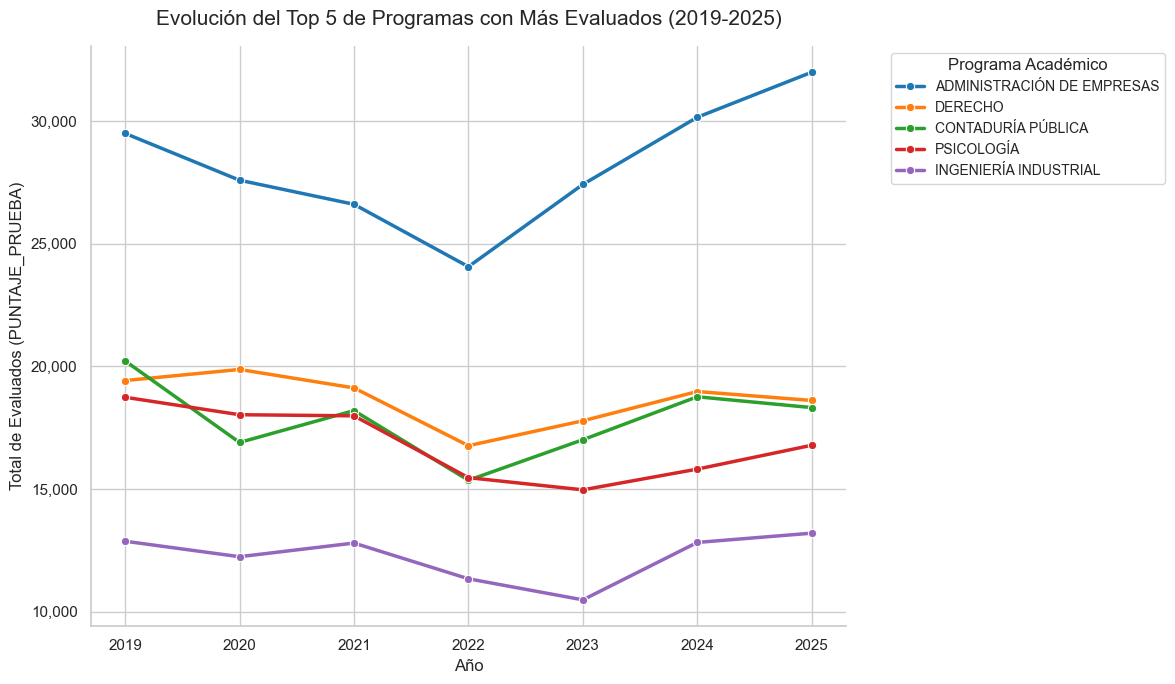

In [33]:
# =============================================================================
# 1. Consulta 3: Tendencia top 5 programas académicos
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
query = """
    WITH ranking AS (
        SELECT t.ANIO, p.nombre_programa_acad AS programa,
               SUM(f.CANTIDADEVALUADOS) AS total_evaluados,
               ROW_NUMBER() OVER (PARTITION BY t.anio ORDER BY SUM(f.CANTIDADEVALUADOS) DESC) AS rn
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_PROGRAMA p ON f.id_programa_acad = p.ID_PROGRAMA_ACAD
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND q.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO' 
          AND f.id_programa_acad IS NOT NULL
        GROUP BY t.ANIO, p.nombre_programa_acad
    )
    SELECT ANIO, programa, total_evaluados
    FROM ranking WHERE rn <= 5
    ORDER BY ANIO, total_evaluados DESC;
"""
df_top5 = pd.read_sql(query, conn)
conn.close()
print(df_top5)

# =============================================================================
# 2. PREPARACIÓN PARA SEABORN
# =============================================================================
# Forzar un orden lógico en la leyenda (del más grande al más pequeño en el último año)
orden_top5 = df_top5[df_top5['ANIO'] == 2025]['programa'].tolist()
# Si por alguna razón faltara un año, tomamos el máximo histórico
if not orden_top5:
    orden_top5 = df_top5.groupby('programa')['total_evaluados'].sum().sort_values(ascending=False).head(5).index.tolist()

df_top5['programa'] = pd.Categorical(df_top5['programa'], categories=orden_top5, ordered=True)

# =============================================================================
# 3. VISUALIZACIÓN DE TENDENCIA (Spaghetti Plot Limpio)
# =============================================================================
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_top5, 
    x='ANIO', 
    y='total_evaluados', 
    hue='programa', 
    marker='o', 
    linewidth=2.5,
    palette='tab10'
)

plt.title('Evolución del Top 5 de Programas con Más Evaluados (2019-2025)', fontsize=15, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Evaluados (PUNTAJE_PRUEBA)', fontsize=12)

# Formatear el eje Y con separador de miles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Quitar bordes innecesarios del gráfico
sns.despine()

# Mover leyenda a la derecha para que no tape las líneas
plt.legend(title='Programa Académico', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Asegurar que el eje X muestre solo números enteros (años)
plt.xticks(df_top5['ANIO'].unique())

plt.tight_layout()
plt.savefig('Pruebas_saberpro_2019-2025_T5Prgs.png', dpi=300)
plt.show()

Las gráficas de la consulta 2 y 3 muestran las 5 profesiones con mayor cantidad de estudiantes evaluados por año. Durante el lapso de 2019 a 2025 la prevalencia se encuentra entre **Administración de empresas**, **Ingeniría industrial** (ocupando constantemente el primer y quinto lugar), **Derecho**, **Contaduría pública** y **Psicología** (conservando este orden desde 2022).</br>
Tanto administración como ingeniería industrial y psicología han tenido una tendencia ascendente desde 2023.

   ANIO                                        institucion  total_evaluados
0  2019  UNIMINUTO- CORPORACIÓN UNIVERSITARIA MINUTO DE...            20562
1  2019                         POLITÉCNICO GRANCOLOMBIANO            11110
2  2019                UNIVERSIDAD COOPERATIVA DE COLOMBIA             8091
3  2019    UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNAD             7458
4  2019            FUNDACIÓN UNIVERSITARIA DEL ÁREA ANDINA             6647


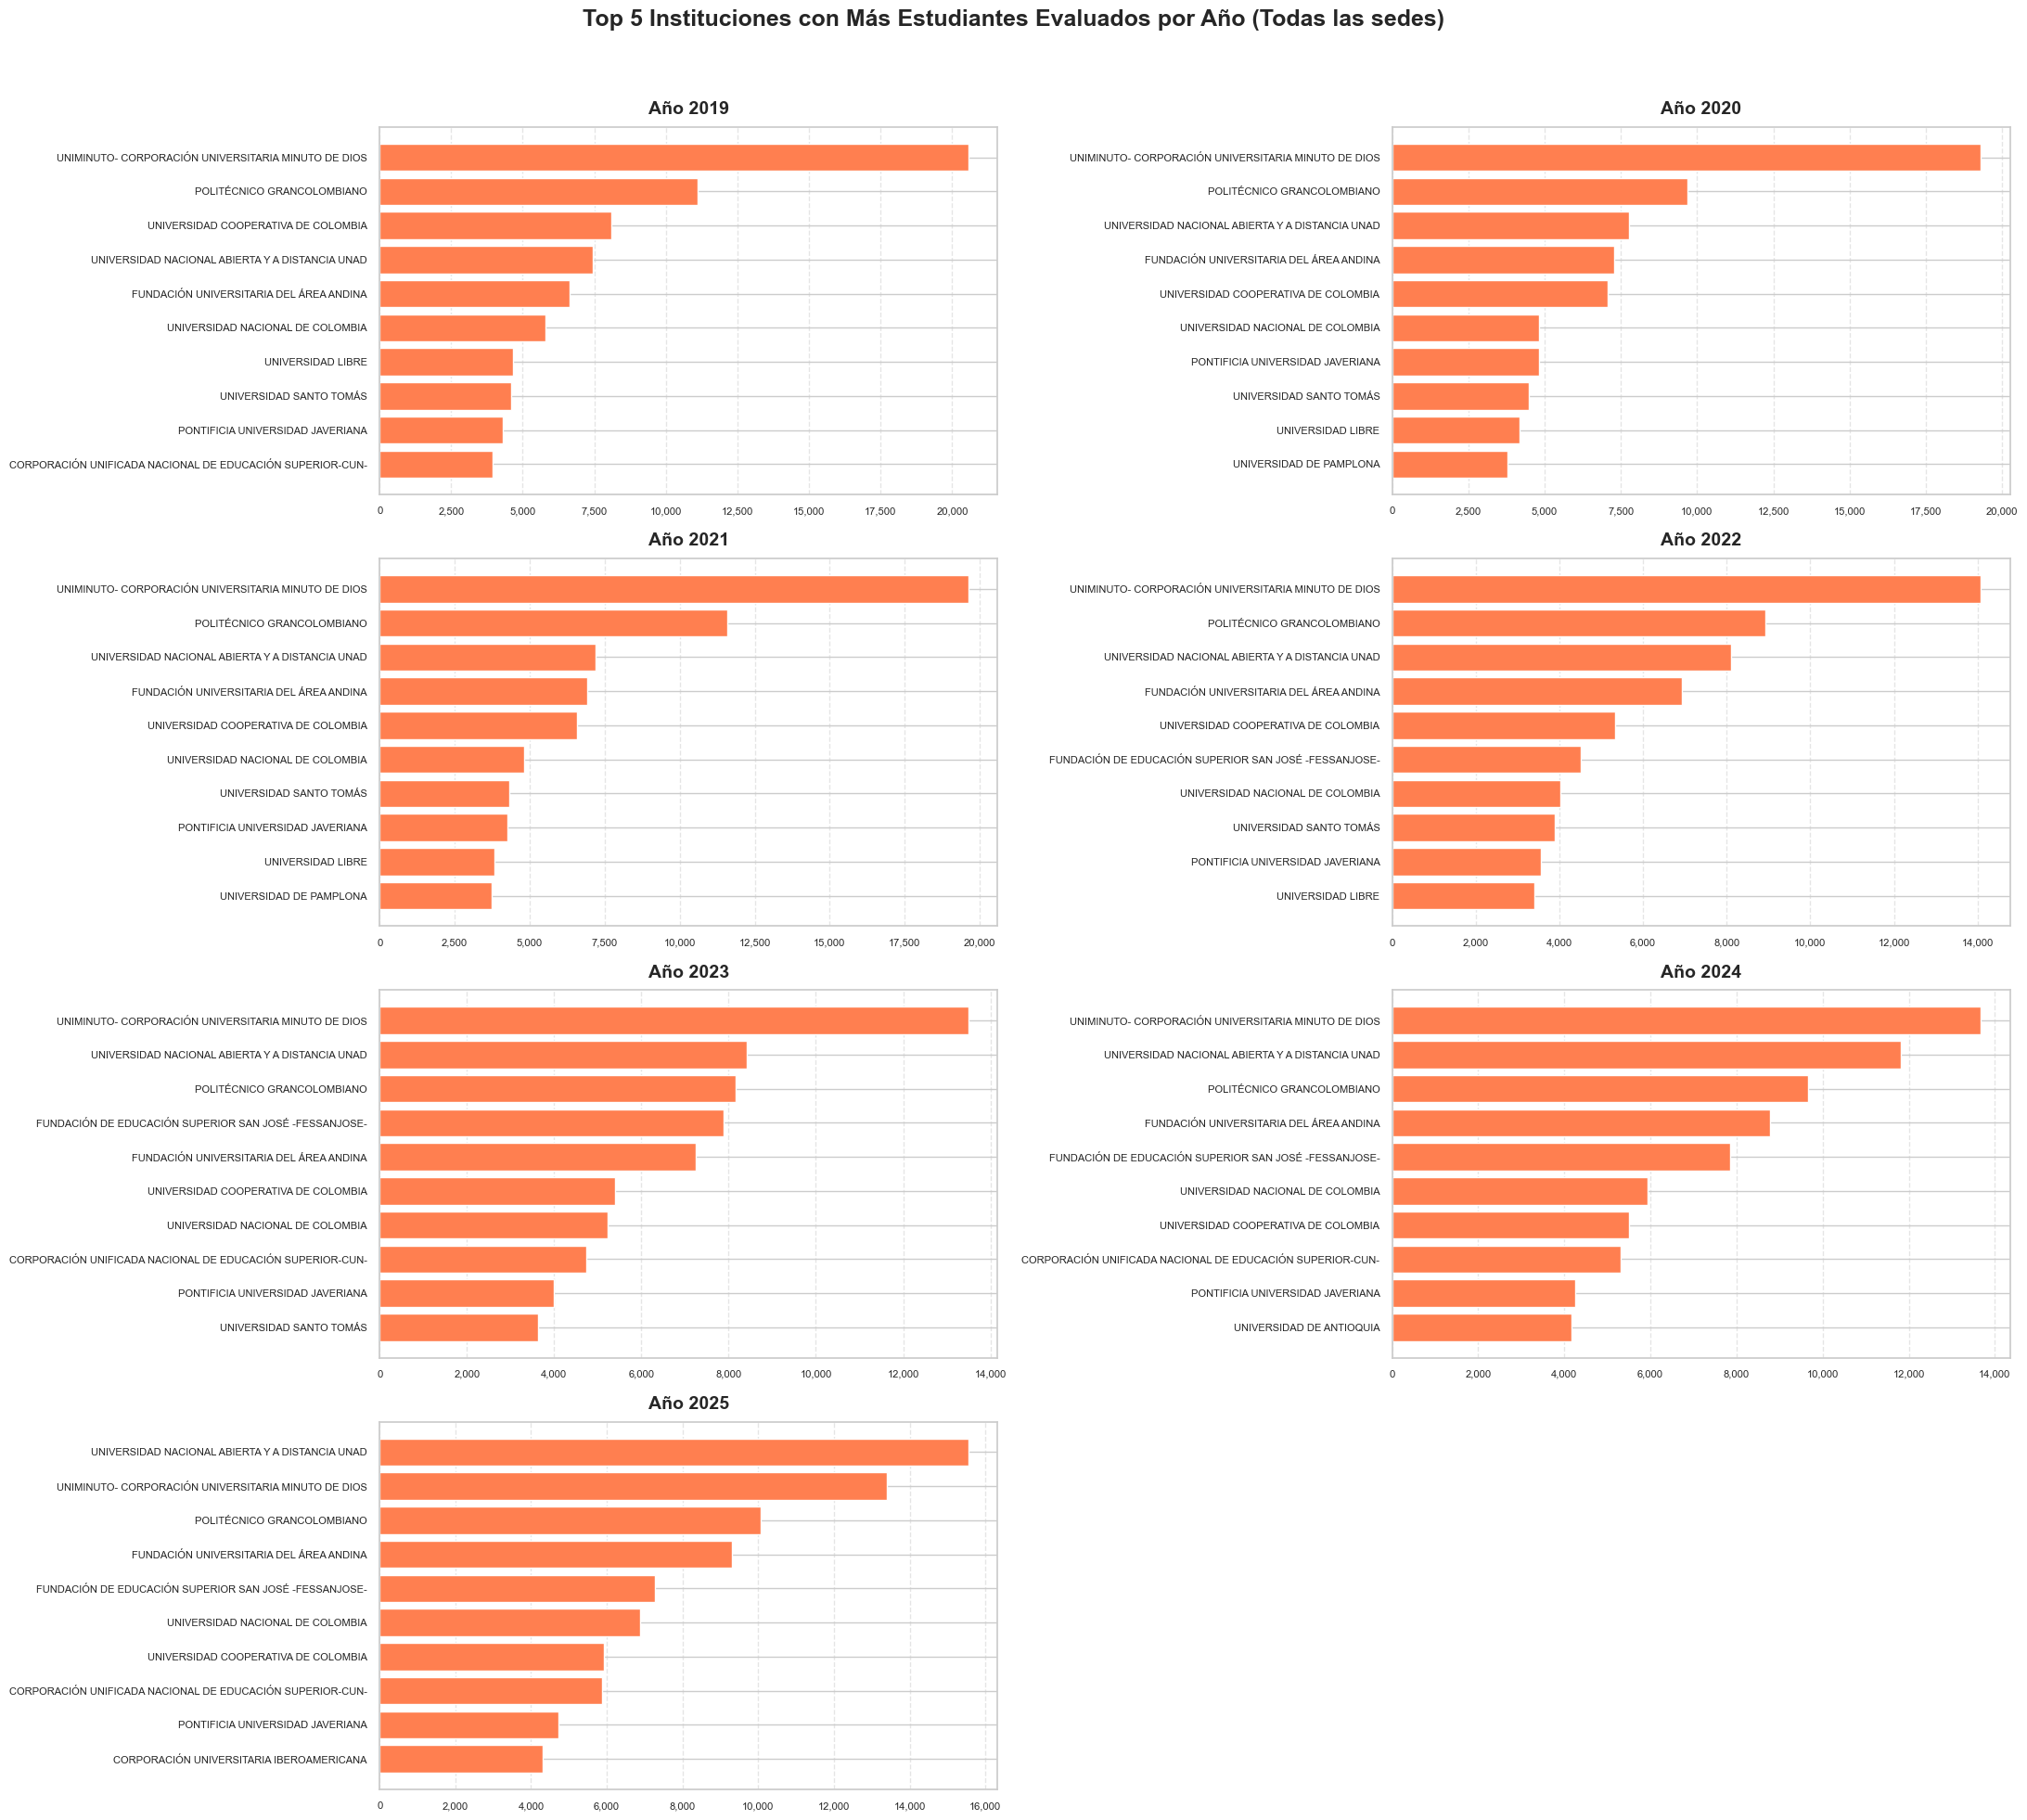

In [36]:
# =============================================================================
# 1. Consulta 4: TOP 5 INSTITUCIONES POR AÑO
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
df_top5_inst = pd.read_sql("""
    WITH ranking AS (
        SELECT t.ANIO, i.NOMBRE_INSTITUCION AS institucion,
               SUM(f.CANTIDADEVALUADOS) AS total_evaluados,
               ROW_NUMBER() OVER (PARTITION BY t.anio ORDER BY SUM(f.CANTIDADEVALUADOS) DESC) AS rn
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_INSTITUCION i ON f.id_inst_sede = i.id_inst_sede
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND q.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO' 
          AND f.id_inst_sede IS NOT NULL
        GROUP BY t.ANIO, i.NOMBRE_INSTITUCION -- Agrupar por nombre suma todas sus sedes
    )
    SELECT ANIO, institucion, total_evaluados
    FROM ranking WHERE rn <= 10
    ORDER BY ANIO, total_evaluados DESC;
""", conn)
conn.close()
print(df_top5_inst.head(10))

# =============================================================================
# 2. CONFIGURACIÓN DINÁMICA DEL GRID
# =============================================================================
anios = sorted(df_top5_inst['ANIO'].unique())
n_anios = len(anios)

ncols = 2
nrows = math.ceil(n_anios / ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 20)) # Un poco más ancho y alto para nombres largos
axes = axes.flatten()

# =============================================================================
# 3. DIBUJO DE GRÁFICOS
# =============================================================================
for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_top5_inst[df_top5_inst['ANIO'] == anio].sort_values('total_evaluados')
    
    ax.barh(df_anio['institucion'], df_anio['total_evaluados'], color='coral', edgecolor='white')
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold', pad=10)
    
    # Reducir fuente aún más porque los nombres de las U. son MUY largos
    ax.tick_params(axis='y', labelsize=8) 
    ax.tick_params(axis='x', labelsize=8)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Formato de miles
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# =============================================================================
# 4. LIMPIEZA Y AJUSTE FINAL
# =============================================================================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Instituciones con Más Estudiantes Evaluados por Año (Todas las sedes)', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Pruebas_saberpro_2019-2025_T10Insts.png', dpi=300)
plt.show()

La gráfica muestra las diez IES con mayor cobertura por año. En general, Uniminuto, Politécnico Grancolombiano, Universidad cooperativa de Colombia, UNAD, Fundación universitaria del area andina, UNAL y la Pontificia universidad javeriana han estado constantemente del 2019 al 2025. Por su parte la Universidad libre (2019 al 2022) y la Universidad Santo Tomás (2019 al 2023) han cedido el lugar en los últimos años. Temporalmente la Universidad de Pamplona estuvo en los primeros 10 lugares entre 2020 y 2021. En tanto que, la Corporación unificada nacional - CUN (2019, 2023 al 2025) ha recuperado cobertura recientemente. También es de destacar el ascenso de IES como la FES - San José (2022 al 2025), Universidad de Antioquia (2024) y la Corporación universitaria iberoamericana (2025).</br>
Históricamente, en el periodo analizado, la IES que ha tenido la mayor cantidad de estudiantes evaluados es Uniminuto en 2019, con 20562 (7.89%) estudiantes. También cabe resaltar que en el mismo periodo las diez IES con mayor cobertura, en cada año, han cubierto entre 29.69% (_2020_ - 73175 estudiantes) y 28,13% (_2022_ - 62728 estudiantes) de la población total evaluada. Para 2025 el 29.36% (83324 estudiantes).

In [46]:
df_top5_inst.to_csv('top10inst2019-2025.csv', index=False, encoding='utf-8-sig')

    ANIO departamento  total_evaluados
0   2019       BOGOTÁ           117136
1   2019    ANTIOQUIA            31586
2   2019    ATLANTICO            16198
3   2019        VALLE            15308
4   2019    SANTANDER            11534
5   2020       BOGOTÁ           113300
6   2020    ANTIOQUIA            27985
7   2020    ATLANTICO            15154
8   2020        VALLE            14116
9   2020    SANTANDER            10818
10  2021       BOGOTÁ           112050
11  2021    ANTIOQUIA            28849
12  2021    ATLANTICO            15315
13  2021        VALLE            14549
14  2021    SANTANDER            10250
15  2022       BOGOTÁ           100151
16  2022    ANTIOQUIA            24867
17  2022    ATLANTICO            14057
18  2022        VALLE            13215
19  2022    SANTANDER             8719
20  2023       BOGOTÁ           106433
21  2023    ANTIOQUIA            25694
22  2023    ATLANTICO            15575
23  2023        VALLE            15298
24  2023    SANTANDER    

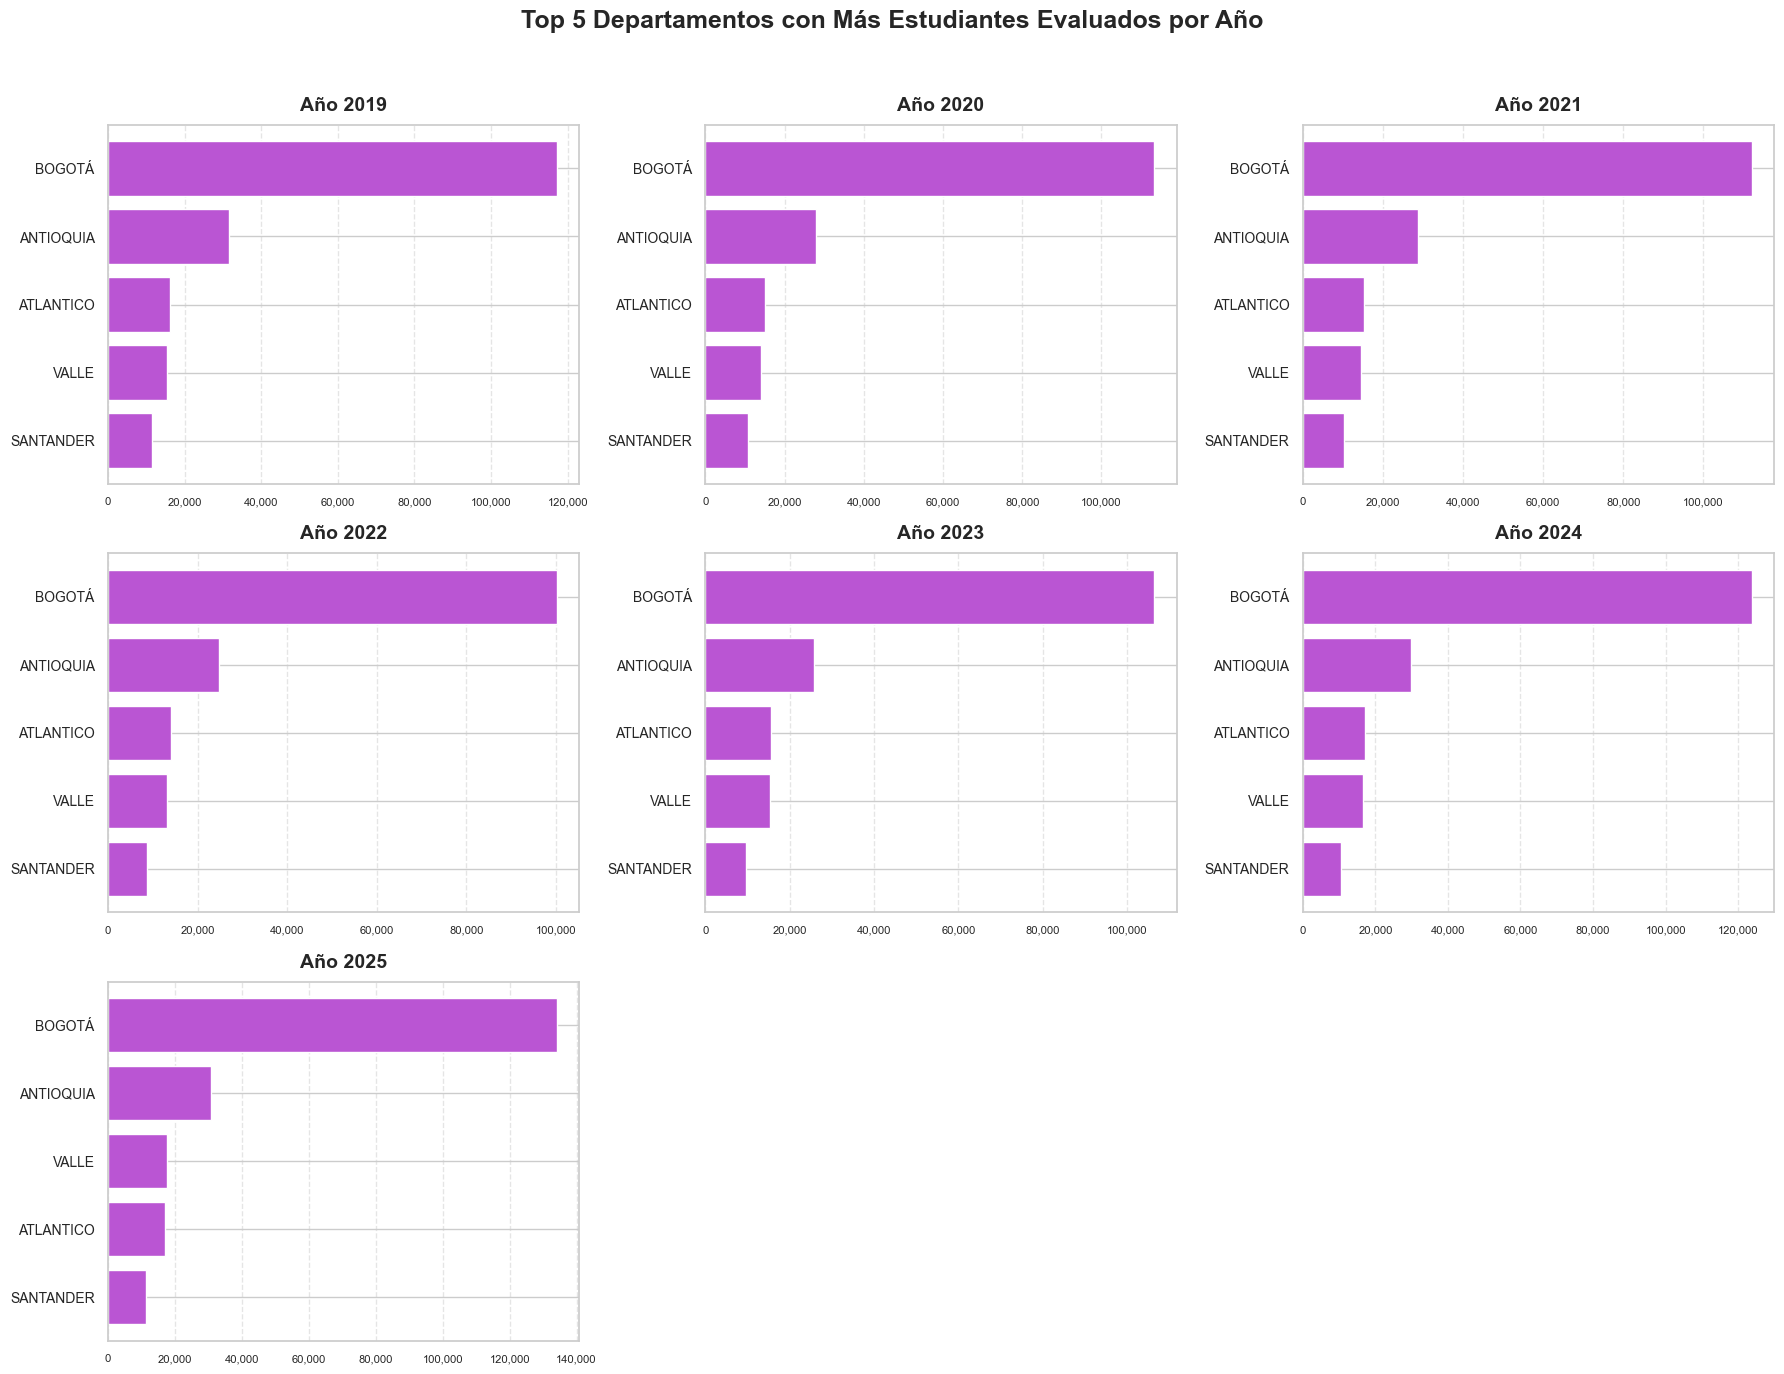

In [39]:
# =============================================================================
# 1. Consulta 5 - TOP 5 DEPARTAMENTOS POR AÑO
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
df_top5_geo = pd.read_sql("""
    WITH ranking AS (
        SELECT t.ANIO, g.NOMBRE_DEPARTAMENTO AS departamento,
               SUM(f.CANTIDADEVALUADOS) AS total_evaluados,
               ROW_NUMBER() OVER (PARTITION BY t.anio ORDER BY SUM(f.CANTIDADEVALUADOS) DESC) AS rn
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_GEOGRAFIA g ON f.id_geografia = g.id_geografia
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND q.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO' 
          AND f.id_geografia IS NOT NULL
        GROUP BY t.ANIO, g.NOMBRE_DEPARTAMENTO
    )
    SELECT ANIO, departamento, total_evaluados
    FROM ranking WHERE rn <= 5
    ORDER BY ANIO, total_evaluados DESC;
""", conn)
conn.close()
print(df_top5_geo)

# =============================================================================
# 2. CONFIGURACIÓN DINÁMICA DEL GRID
# =============================================================================
anios = sorted(df_top5_geo['ANIO'].unique())
n_anios = len(anios)

ncols = 3
nrows = math.ceil(n_anios / ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14))
axes = axes.flatten()

# =============================================================================
# 3. DIBUJO DE GRÁFICOS
# =============================================================================
for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_top5_geo[df_top5_geo['ANIO'] == anio].sort_values('total_evaluados')
    
    # Usamos un color púrpura/magenta para diferenciar de los anteriores
    ax.barh(df_anio['departamento'], df_anio['total_evaluados'], color='mediumorchid', edgecolor='white')
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold', pad=10)
    
    ax.tick_params(axis='y', labelsize=10) # Fuente un poco más grande para leer bien los dptos
    ax.tick_params(axis='x', labelsize=8)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# =============================================================================
# 4. LIMPIEZA Y AJUSTE FINAL
# =============================================================================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Departamentos con Más Estudiantes Evaluados por Año', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Pruebas_saberpro_2019-2025_T5geogr.png', dpi=300)
plt.show()

En relación con la gráfica de distribución geográfica de mayor cobertura, Bogotá conserva la mayor proporción, anualmente se han evaluado entre el 44.62% y 47.23% (siendo esta última la más reciente), seguido por Antioquia entre el 10.77% al 12.11%. Cabe resaltar que, aunque la tercera posición la venía ocupando el Atlántico, el Valle progresivamente ha aumentado cobertura al punto de superar al Atlántico en 2025. Entre ambos departamentos suman alrededor de otro 12%. El departamento de Santander gira en torno a un 4%.</br>
Los 5 combinados abarcan entre el  72.2% (2022) y el 74.33% (2025) de los evaluados.

    ANIO                     prueba  puntaje_promedio_nacional
0   2019    COMPETENCIAS CIUDADANAS                     143.70
1   2019       COMUNICACIÓN ESCRITA                     143.74
2   2019                     INGLÉS                     155.83
3   2019            LECTURA CRÍTICA                     151.33
4   2019  RAZONAMIENTO CUANTITATIVO                     149.54
5   2020    COMPETENCIAS CIUDADANAS                     154.26
6   2020       COMUNICACIÓN ESCRITA                     138.20
7   2020                     INGLÉS                     158.99
8   2020            LECTURA CRÍTICA                     153.92
9   2020  RAZONAMIENTO CUANTITATIVO                     151.07
10  2021    COMPETENCIAS CIUDADANAS                     145.10
11  2021       COMUNICACIÓN ESCRITA                     139.00
12  2021                     INGLÉS                     156.99
13  2021            LECTURA CRÍTICA                     148.42
14  2021  RAZONAMIENTO CUANTITATIVO                    

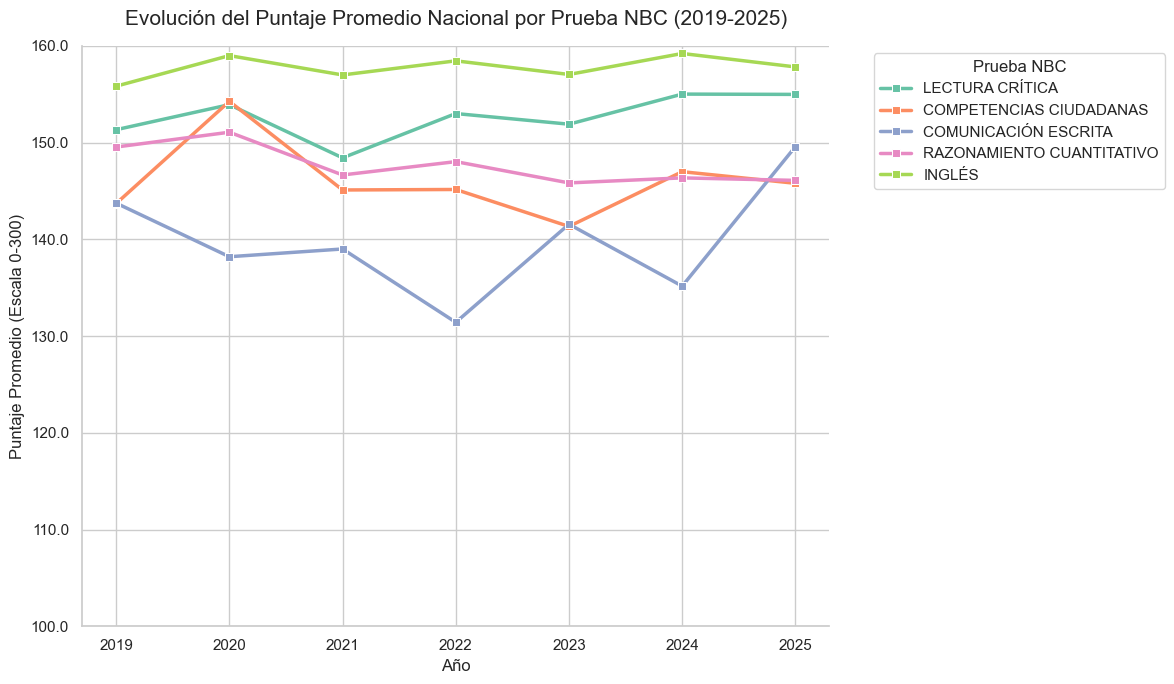

In [40]:
# =============================================================================
# 1. Consulta 6: EVOLUCIÓN PUNTAJES NBC
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
query_nbc = """
    -- Paso 1: Calcular el promedio de CADA programa en CADA año
    WITH promedios_programas AS (
        SELECT 
            t.ANIO,
            p.NOMBRE_PRUEBA AS prueba,
            AVG(f.PROMEDIO_PRUEBA) AS promedio_programa
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_PROGRAMA pr ON f.ID_PROGRAMA_ACAD = pr.ID_PROGRAMA_ACAD
        JOIN DIM_PRUEBA p ON f.id_prueba = p.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND p.NOMBRE_PRUEBA IN (
              'COMPETENCIAS CIUDADANAS', 
              'COMUNICACIÓN ESCRITA', 
              'LECTURA CRÍTICA', 
              'RAZONAMIENTO CUANTITATIVO', 
              'INGLÉS'
          )
          AND f.PROMEDIO_PRUEBA IS NOT NULL -- Ignorar programas sin datos de puntaje
        GROUP BY t.ANIO, pr.ID_PROGRAMA_ACAD, p.NOMBRE_PRUEBA
    )
    -- Paso 2: Sacar el promedio nacional de los promedios de los programas
    SELECT 
        ANIO, 
        prueba, 
        ROUND(AVG(promedio_programa), 2) AS puntaje_promedio_nacional
    FROM promedios_programas
    GROUP BY ANIO, prueba
    ORDER BY ANIO, prueba;
"""

df_nbc = pd.read_sql(query_nbc, conn)
conn.close()
print(df_nbc)

# =============================================================================
# 2. PREPARACIÓN PARA SEABORN
# =============================================================================
orden_pruebas = [
    'LECTURA CRÍTICA', 
    'COMPETENCIAS CIUDADANAS', 
    'COMUNICACIÓN ESCRITA', 
    'RAZONAMIENTO CUANTITATIVO', 
    'INGLÉS'
]
df_nbc['prueba'] = pd.Categorical(df_nbc['prueba'], categories=orden_pruebas, ordered=True)

# =============================================================================
# 3. VISUALIZACIÓN DE TENDENCIA
# =============================================================================
# Usamos un estilo un poco más formal para esta gráfica de "resultados"
sns.set_theme(style="whitegrid") 

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_nbc, 
    x='ANIO', 
    y='puntaje_promedio_nacional', 
    hue='prueba', 
    marker='s', # Marcadores cuadrados para diferenciar de las de volumen
    linewidth=2.5,
    palette='Set2' # Paleta con colores suaves pero distintos
)

plt.title('Evolución del Puntaje Promedio Nacional por Prueba NBC (2019-2025)', fontsize=15, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Puntaje Promedio (Escala 0-300)', fontsize=12)

# Asegurar que el eje Y empieze en un número razonable (ej. 100) para ver las variaciones
plt.ylim(100, 160) # Ajusta estos valores si es necesario tras ver el resultado real

# Formatear el eje Y con 1 decimal (ej: 125.5)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

sns.despine()
plt.legend(title='Prueba NBC', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(df_nbc['ANIO'].unique())

plt.tight_layout()
plt.savefig('Pruebas_saberpro_2019-2025_NBVevol.png', dpi=300)
plt.show()

# Quitar el tema para las siguientes gráficas si no te gusta
sns.set_theme(style="darkgrid") 

La gráfica muestra el comportamiento del rendimiento promedio en cada núcleo básico general. Si bien se acercan al rendimiento esperado, alrededor de la puntuación de 150, solo los componentes de inglés y lectura crítica suelen superarla, en tanto que razonamiento cuantitativo, comunicación escrita y competencias ciudadanas suelen ser inferiores a la puntuación esperada.</br>
Es de resaltar que el rendimiento en **inglés suele ser el más alto y sostenido**, mientras que, en contraste, la **comunicación escrita tiene el rendimiento más bajo**, aunque también es particularmente llamativo el hecho de que **mejoró sustancialmente el último año evaluado**, superando a la lectura crítica y las competencias ciudadanas.

    ANIO                                        institucion  \
0   2019                           UNIVERSIDAD DE LOS ANDES   
1   2019  COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACI...   
2   2019                                    UNIVERSIDAD EIA   
3   2019                                  UNIVERSIDAD ICESI   
4   2019        COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO   
5   2020                           UNIVERSIDAD DE LOS ANDES   
6   2020  COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACI...   
7   2020                                    UNIVERSIDAD EIA   
8   2020                           UNIVERSIDAD DE LA SABANA   
9   2020                   UNIVERSIDAD NACIONAL DE COLOMBIA   
10  2021                           UNIVERSIDAD DE LOS ANDES   
11  2021                           UNIVERSIDAD DE LA SABANA   
12  2021                                    UNIVERSIDAD EIA   
13  2021  COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACI...   
14  2021                                  UNIVERSIDAD I

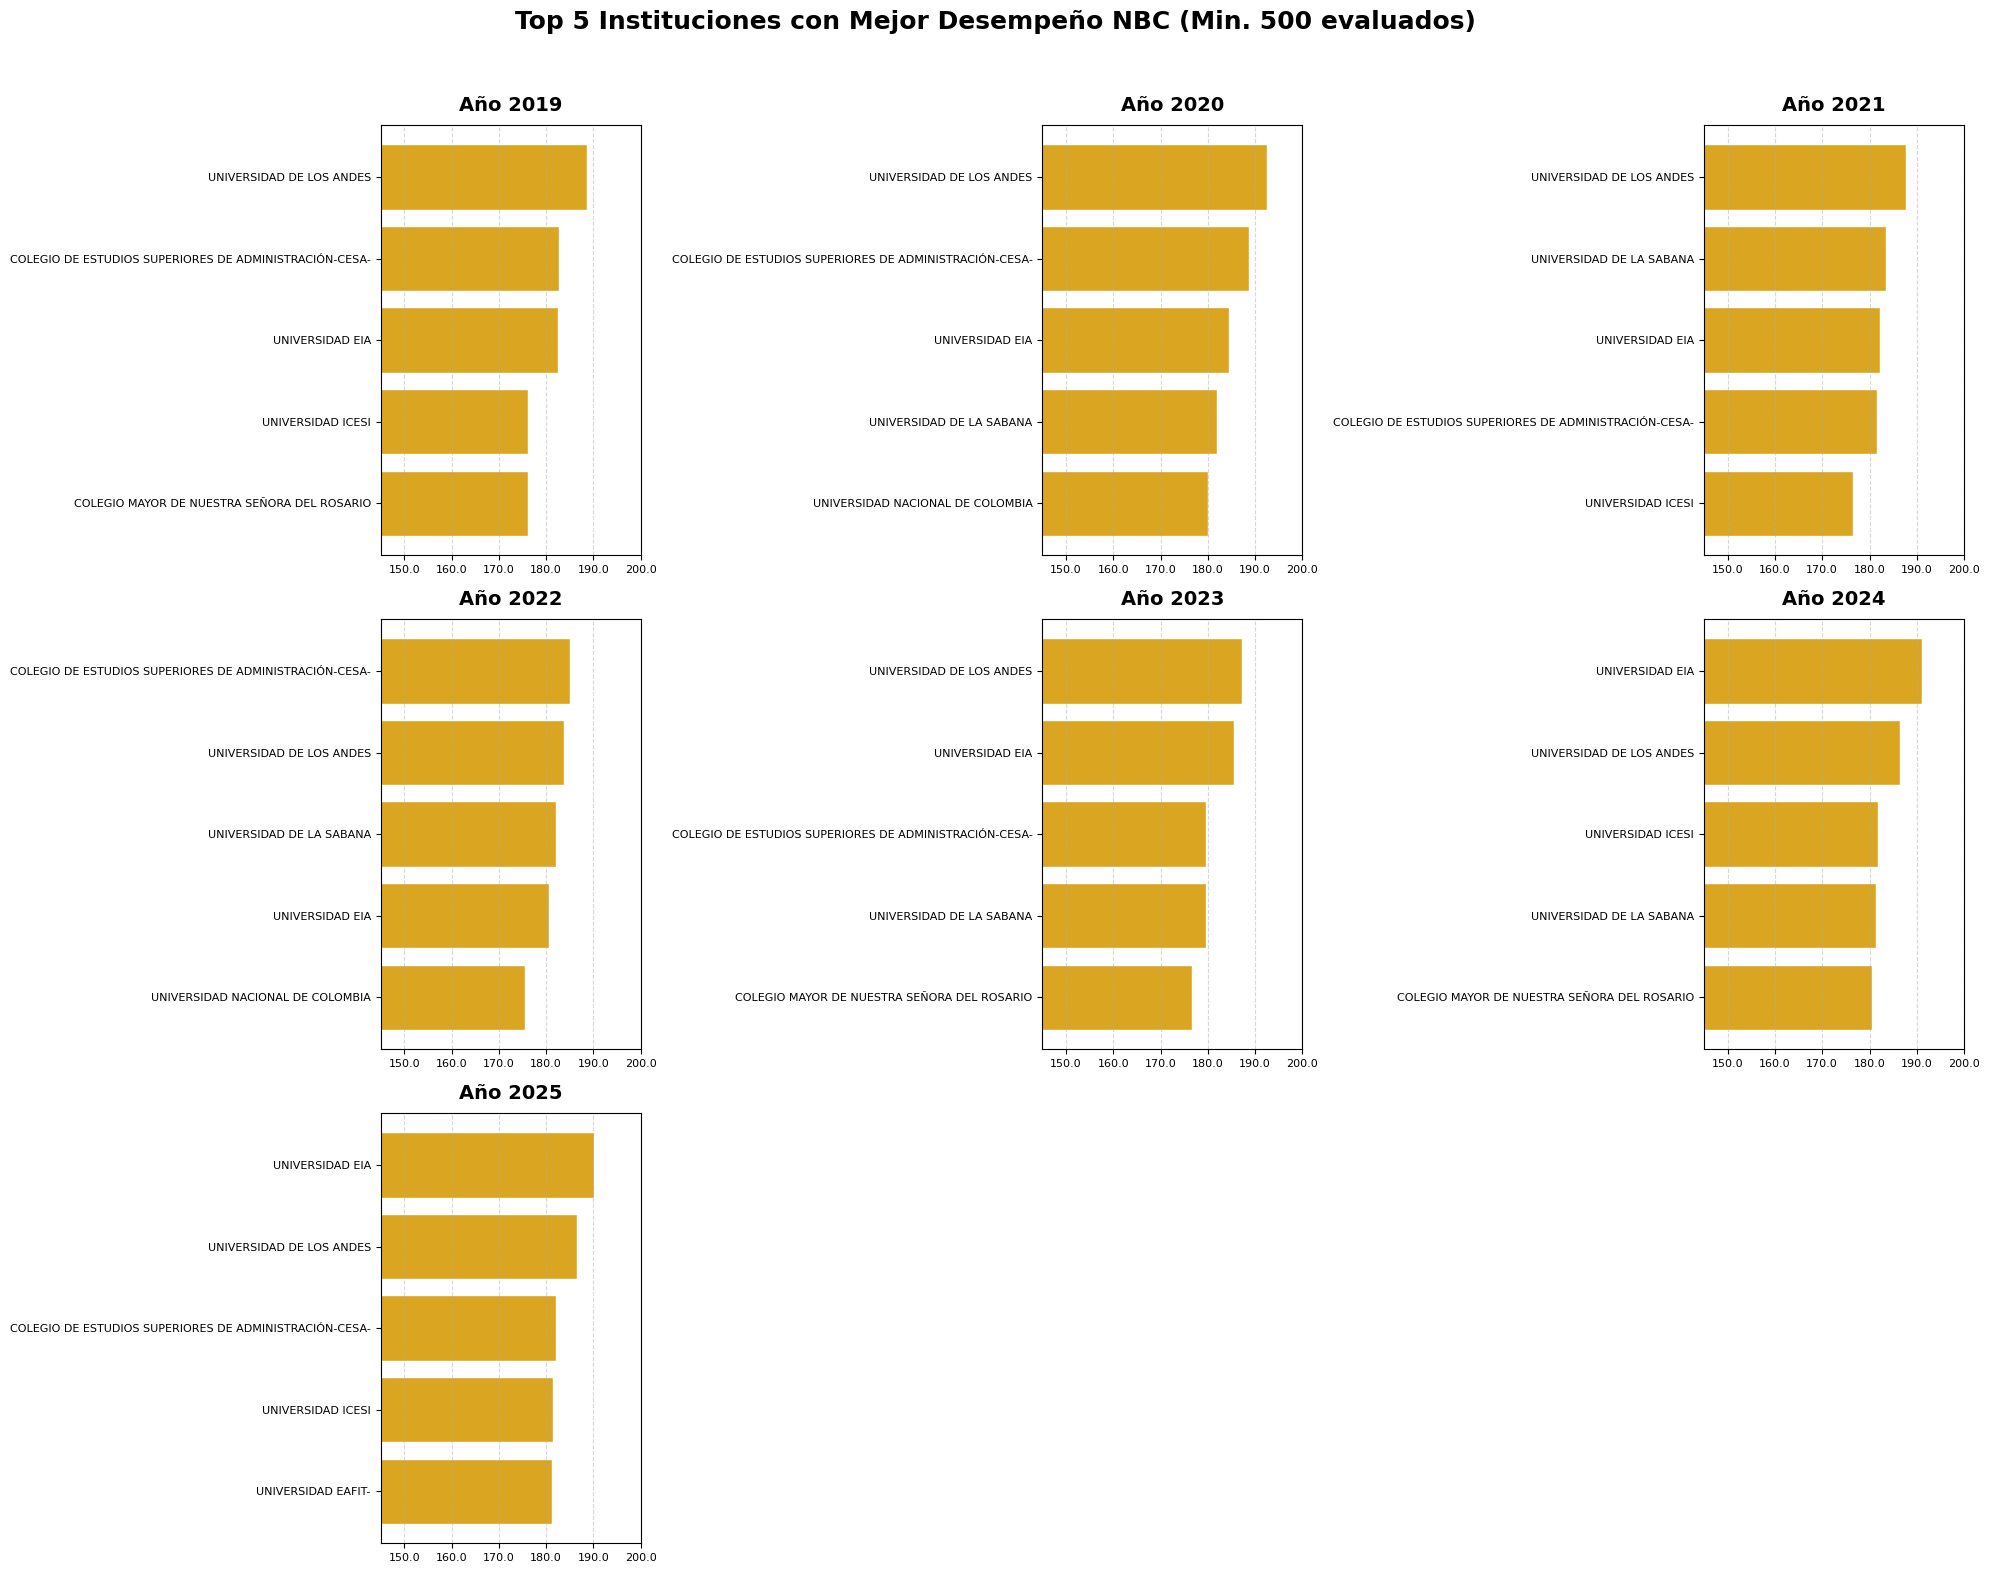

In [2]:
# =============================================================================
# 1. Consulta 7: TOP 5 INSTITUCIONES POR MEJOR PUNTAJE NBC PROMEDIO
# =============================================================================
conn = sqlite3.connect('saberpro_star_schema.db')
df_top5_calidad = pd.read_sql("""
    WITH promedios_inst AS (
        -- Paso 1: Sacar el promedio de las 5 pruebas NBC por cada sede/programa/año
        SELECT 
            t.ANIO,
            i.NOMBRE_INSTITUCION AS institucion,
            SUM(f.CANTIDADEVALUADOS) AS total_evaluados,
            AVG(f.PROMEDIO_PRUEBA) AS puntaje_promedio_nbc
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_INSTITUCION i ON f.id_inst_sede = i.id_inst_sede
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND q.NOMBRE_PRUEBA IN (
              'COMPETENCIAS CIUDADANAS', 'COMUNICACIÓN ESCRITA', 
              'LECTURA CRÍTICA', 'RAZONAMIENTO CUANTITATIVO', 'INGLÉS'
          )
          AND f.PROMEDIO_PRUEBA IS NOT NULL
        GROUP BY t.ANIO, i.NOMBRE_INSTITUCION
        HAVING SUM(f.CANTIDADEVALUADOS) >= 500 -- <--- LA REGLA DE ORO: Mínimo 500 evaluados para evitar sesgos
    ),
    ranking AS (
        -- Paso 2: Agrupar por institución (suma todas sus sedes) y rankear
        SELECT 
            ANIO, 
            institucion,
            SUM(total_evaluados) AS poblacion_total_valida,
            AVG(puntaje_promedio_nbc) AS puntaje_global,
            ROW_NUMBER() OVER (PARTITION BY ANIO ORDER BY AVG(puntaje_promedio_nbc) DESC) AS rn
        FROM promedios_inst
        GROUP BY ANIO, institucion
    )
    SELECT ANIO, institucion, poblacion_total_valida, ROUND(puntaje_global, 2) AS puntaje
    FROM ranking WHERE rn <= 5
    ORDER BY ANIO, puntaje DESC;
""", conn)
conn.close()
print(df_top5_calidad)

# =============================================================================
# 2. CONFIGURACIÓN DEL GRID (3x3)
# =============================================================================
anios = sorted(df_top5_calidad['ANIO'].unique())
n_anios = len(anios)

ncols = 3
nrows = math.ceil(n_anios / ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16))
axes = axes.flatten()

# =============================================================================
# 3. DIBUJO DE GRÁFICOS
# =============================================================================
for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_top5_calidad[df_top5_calidad['ANIO'] == anio].sort_values('puntaje')
    
    # Paleta dorada/platino para denotar "Calidad/Prestigio"
    ax.barh(df_anio['institucion'], df_anio['puntaje'], color='goldenrod', edgecolor='white')
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold', pad=10)
    
    ax.tick_params(axis='y', labelsize=8) 
    ax.tick_params(axis='x', labelsize=8)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Formatear el eje X para mostrar 1 decimal (ej: 165.4)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    
    # Limitar el eje X para que los cambios mínimos se noten (usualmente están entre 150 y 175)
    ax.set_xlim(145, 200)

# =============================================================================
# 4. LIMPIEZA Y AJUSTE FINAL
# =============================================================================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Instituciones con Mejor Desempeño NBC (Min. 500 evaluados)', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Pruebas_saberpro_2019-2025_T5HQinst.png', dpi=300)
plt.show()

C:\Users\NaujAlkml\AppData\Local\Temp\ipykernel_12648\3997590625.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top5_final = df_top5_calidad.groupby('ANIO', group_keys=False).apply(get_top5).reset_index(drop=True)


    ANIO                                        institucion  total_evaluados  \
0   2019                           UNIVERSIDAD DE LOS ANDES            14913   
1   2019  COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACI...             1043   
2   2019                                    UNIVERSIDAD EIA             1574   
3   2019                                  UNIVERSIDAD ICESI             5028   
4   2019                   UNIVERSIDAD NACIONAL DE COLOMBIA            29007   
5   2020                           UNIVERSIDAD DE LOS ANDES            14375   
6   2020  COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACI...             1110   
7   2020                                    UNIVERSIDAD EIA             1410   
8   2020                           UNIVERSIDAD DE LA SABANA             9475   
9   2020                   UNIVERSIDAD NACIONAL DE COLOMBIA            24150   
10  2021                           UNIVERSIDAD DE LOS ANDES            12995   
11  2021                           UNIVE

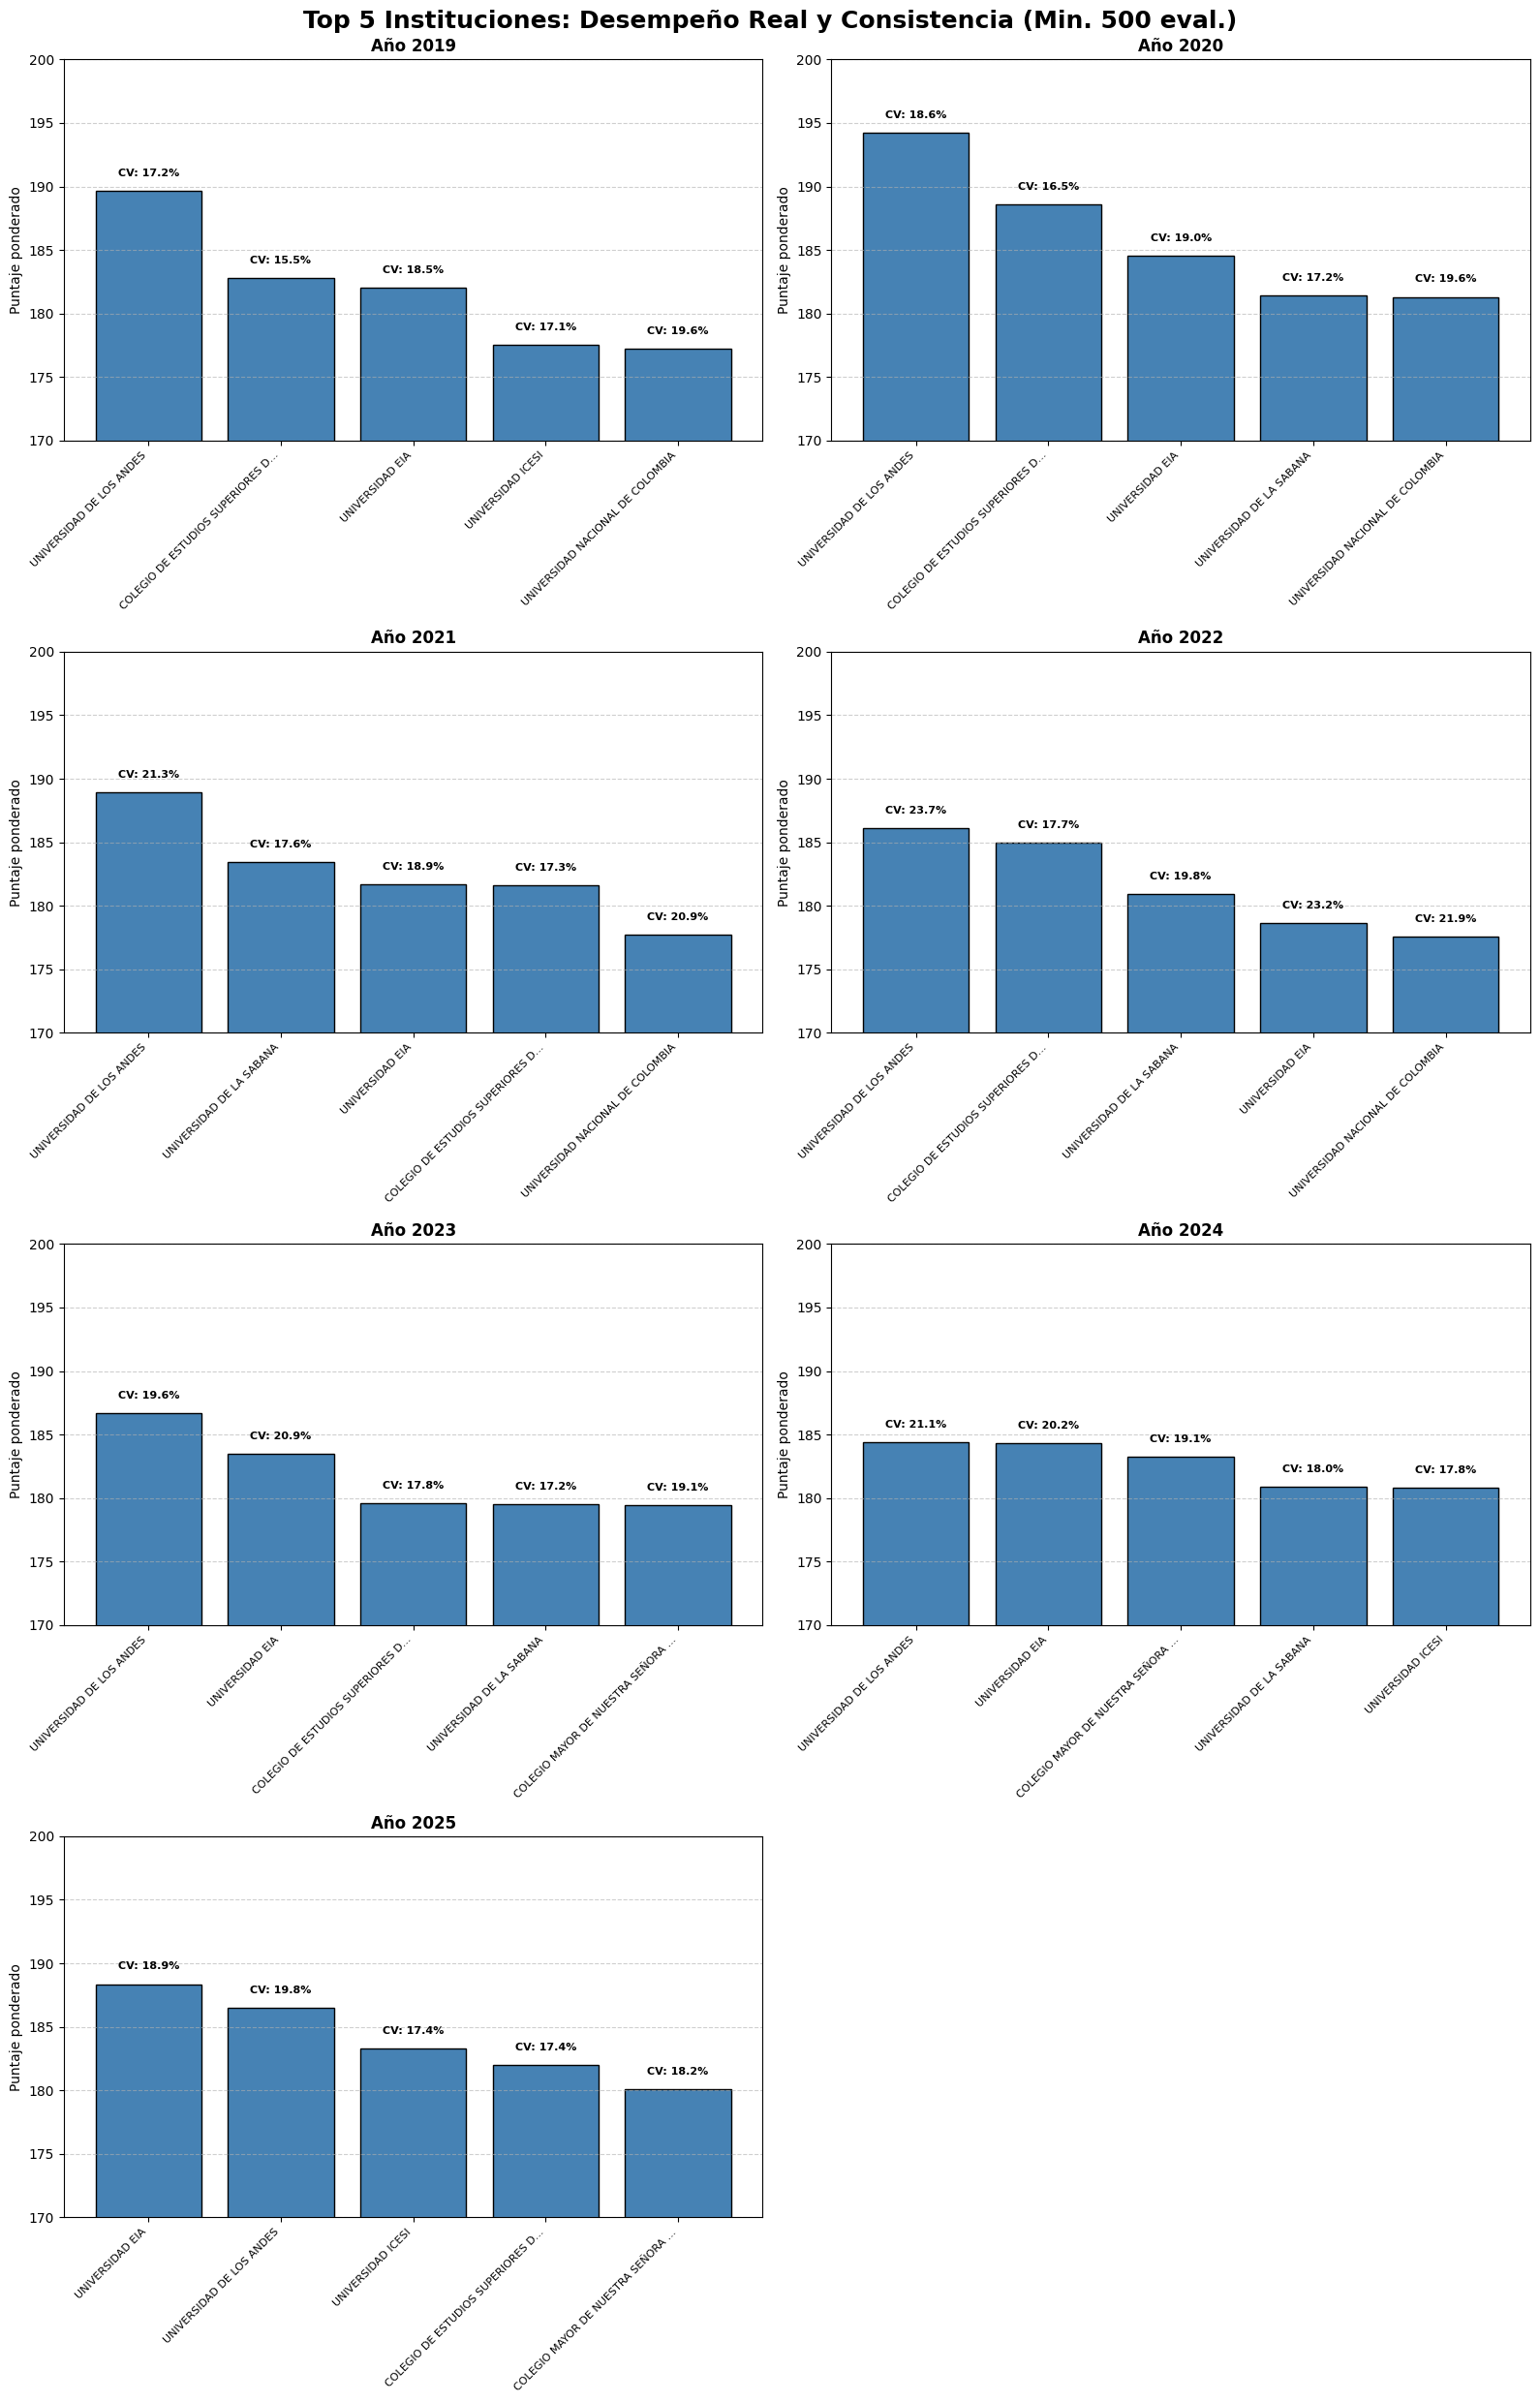

In [16]:
# Consulta 8: Top 5 de programas con mayor puntaje (SD-ponderada)
# 1. Cargar los "ladrillos" desde SQL
conn = sqlite3.connect('saberpro_star_schema.db')
df_top5_calidad = pd.read_sql("""
    WITH metricas_base AS (
        SELECT 
            t.ANIO,
            i.NOMBRE_INSTITUCION AS institucion,
            f.CANTIDADEVALUADOS AS n,
            f.PROMEDIO_PRUEBA AS prom,
            f.DESVIACION AS desv
        FROM FACT_RESULTADOS f
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_INSTITUCION i ON f.id_inst_sede = i.id_inst_sede
        JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO' 
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND q.NOMBRE_PRUEBA IN (
              'COMPETENCIAS CIUDADANAS', 'COMUNICACIÓN ESCRITA', 
              'LECTURA CRÍTICA', 'RAZONAMIENTO CUANTITATIVO', 'INGLÉS'
          )
          AND f.PROMEDIO_PRUEBA IS NOT NULL
    ),
    metricas_calculadas AS (
        SELECT 
            ANIO, 
            institucion,
            SUM(n) AS total_evaluados,
            
            -- PROMEDIO PONDERADO 
            ROUND(SUM(n * prom) / SUM(n), 2) AS puntaje_real,
            
            -- VARIANZA PONDERADA [E(X^2) - E(X)^2] 
            -- Ojo: 'prom * prom + desv * desv' es igual a la Varianza de esa muestra específica
            (SUM(n * (prom * prom + desv * desv)) / SUM(n)) - (SUM(n * prom) / SUM(n)) * (SUM(n * prom) / SUM(n)) AS varianza_pond
                
        FROM metricas_base
        GROUP BY ANIO, institucion
        HAVING SUM(n) >= 500
    )
    SELECT * 
    FROM metricas_calculadas
    ORDER BY ANIO, puntaje_real DESC;
""", conn)
conn.close()

# 2. LA MAGIA MATEMÁTICA: Aplicar la raíz cuadrada y el CV usando Numpy
# np.sqrt es súper rápido y preciso frente a millones de filas
df_top5_calidad['desviacion_real'] = np.sqrt(df_top5_calidad['varianza_pond'])
df_top5_calidad['cv_porcentaje'] = (df_top5_calidad['desviacion_real'] / df_top5_calidad['puntaje_real']) * 100

# Redondear estéticamente para la visualización
df_top5_calidad['desviacion_real'] = df_top5_calidad['desviacion_real'].round(2)
df_top5_calidad['cv_porcentaje'] = df_top5_calidad['cv_porcentaje'].round(1)

# 3. Filtrar solo el Top 5 por año (después de calcular las métricas reales)
def get_top5(group):
    return group.sort_values('puntaje_real', ascending=False).head(5)

df_top5_final = df_top5_calidad.groupby('ANIO', group_keys=False).apply(get_top5).reset_index(drop=True)
print(df_top5_final.head(35))

# 4. VISUALIZACIÓN (El mismo código de antes, pero con datos reales)
# Función auxiliar para evitar que los nombres se solapen
def truncar_texto(texto, max_len=35):
    return texto[:max_len-3] + '...' if len(texto) > max_len else texto

anios = sorted(df_top5_final['ANIO'].unique())
ncols = 2
nrows = math.ceil(len(anios) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 25))
axes = axes.flatten()

for i, anio in enumerate(anios):
    ax = axes[i]
    df_anio = df_top5_final[df_top5_final['ANIO'] == anio].copy()
    # Orden descendente para mostrar el mejor primero
    df_anio = df_anio.sort_values('puntaje_real', ascending=False)
    df_anio['institucion_trunc'] = df_anio['institucion'].apply(truncar_texto)
    
    x = range(len(df_anio))
    bars = ax.bar(x, df_anio['puntaje_real'], color='steelblue', edgecolor='black')
    
    # Etiquetas CV encima de cada barra
    for j, (idx, row) in enumerate(df_anio.iterrows()):
        ax.text(j, row['puntaje_real'] + 1.0, f"CV: {row['cv_porcentaje']}%",
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(df_anio['institucion_trunc'], rotation=45, ha='right', fontsize=8)
    ax.set_ylim(170, 200)   # rango ajustado a tus datos
    ax.set_title(f'Año {anio}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Puntaje ponderado')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# =============================================================================
# 5. LIMPIEZA Y AJUSTE DE MÁRGENES (El asesino del Warning)
# =============================================================================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Instituciones: Desempeño Real y Consistencia (Min. 500 eval.)', 
             fontsize=18, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('Pruebas_saberpro_2019-2025_T5HQinst2.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis previos
Sugeridos por DS.

In [2]:
# Consulta 1: Top 10 programas con mayor crecimiento de promedio entre 2019 y 2025
conn = sqlite3.connect('saberpro_star_schema.db')
df_top10 = pd.read_sql("""
    WITH promedios AS (
        SELECT 
            p.ID_PROGRAMA_ACAD,
            p.NOMBRE_PROGRAMA_ACAD,
            t.ANIO,
            AVG(f.PROMEDIO_PRUEBA) AS prom
        FROM FACT_RESULTADOS f
        JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
        JOIN DIM_TIEMPO t ON f.id_tiempo = t.id_tiempo
        JOIN DIM_PRUEBA pr ON f.id_prueba = pr.id_prueba
        WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
          AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
          AND pr.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO'  -- usar una prueba común
          AND t.ANIO IN (2019, 2025)
        GROUP BY p.ID_PROGRAMA_ACAD, p.NOMBRE_PROGRAMA_ACAD, t.ANIO
    )
    SELECT 
        NOMBRE_PROGRAMA_ACAD,
        ROUND(MAX(CASE WHEN ANIO = 2019 THEN prom END), 2) AS prom_2019,
        ROUND(MAX(CASE WHEN ANIO = 2025 THEN prom END), 2) AS prom_2025,
        ROUND(MAX(CASE WHEN ANIO = 2025 THEN prom END) - MAX(CASE WHEN ANIO = 2019 THEN prom END), 2) AS incremento
    FROM promedios
    GROUP BY ID_PROGRAMA_ACAD, NOMBRE_PROGRAMA_ACAD
    HAVING prom_2019 IS NOT NULL AND prom_2025 IS NOT NULL
    ORDER BY incremento DESC
    LIMIT 10;
""", conn)
conn.close()

print(df_top10)

                                NOMBRE_PROGRAMA_ACAD  prom_2019  prom_2025  \
0                                     ARTE DRAMÁTICO      124.0      203.0   
1                         ADMINISTRACIÓN DE EMPRESAS      136.0      198.0   
2                              INGENIERÍA INDUSTRIAL      149.0      211.0   
3                              MERCADEO Y PUBLICIDAD      142.0      203.0   
4                 LICENCIATURA EN CIENCIAS NATURALES      136.0      196.0   
5                        LICENCIATURA EN MATEMÁTICAS      190.0      248.0   
6                                        MATEMÁTICAS      145.0      200.0   
7                                        MATEMÁTICAS      216.0      269.0   
8  LICENCIATURA EN EDUCACIÓN BÁSICA CON ÉNFASIS E...      143.0      195.0   
9                                 DIRECCIÓN DE BANDA      124.0      170.0   

   incremento  
0        79.0  
1        62.0  
2        62.0  
3        61.0  
4        60.0  
5        58.0  
6        55.0  
7        53.0

In [9]:
# Consulta 2: Departamentos con mejor rendimiento en RAZONAMIENTO CUANTITATIVO (promedio general)

conn = sqlite3.connect('saberpro_star_schema.db')
df_razqnt = pd.read_sql("""
    SELECT 
        g.NOMBRE_DEPARTAMENTO,
        ROUND(AVG(f.PROMEDIO_PRUEBA), 2) AS promedio,
        SUM(f.CANTIDADEVALUADOS) AS total_estudiantes
    FROM FACT_RESULTADOS f
    JOIN DIM_GEOGRAFIA g ON f.id_geografia = g.id_geografia
    JOIN DIM_PRUEBA p ON f.id_prueba = p.id_prueba
    WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
      AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
      AND p.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO'
    GROUP BY g.NOMBRE_DEPARTAMENTO
    HAVING total_estudiantes >= 1000   -- para evitar desviaciones por muestras pequeñas
    ORDER BY promedio DESC
    LIMIT 10;
""", conn)
conn.close()

print(df_razqnt)

  NOMBRE_DEPARTAMENTO  promedio  total_estudiantes
0        CUNDINAMARCA    158.47              26440
1              CALDAS    154.31              24727
2              BOYACA    153.69              34461
3           ANTIOQUIA    151.14             199714
4                META    150.06               7301
5           SANTANDER    149.88              72863
6               VALLE    149.84             106788
7              BOGOTÁ    148.74             806821
8             QUINDIO    147.10              20259
9              NARIÑO    146.78              31224


In [10]:
# Consulta 3: Correlación entre cantidad de estudiantes y desviación estándar (equidad)
conn = sqlite3.connect('saberpro_star_schema.db')
df_est_sd = pd.read_sql("""
    SELECT 
        p.NOMBRE_PROGRAMA_ACAD,
        SUM(f.CANTIDADEVALUADOS) AS total_estudiantes,
        ROUND(AVG(f.DESVIACION), 2) AS desviacion_promedio
    FROM FACT_RESULTADOS f
    JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
    JOIN DIM_PRUEBA pr ON f.id_prueba = pr.id_prueba
    WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
      AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
      AND pr.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO'
      AND f.DESVIACION IS NOT NULL
    GROUP BY p.NOMBRE_PROGRAMA_ACAD
    HAVING total_estudiantes >= 500
    ORDER BY desviacion_promedio DESC
    LIMIT 20;
""", conn)
conn.close()

print(df_est_sd)

                                 NOMBRE_PROGRAMA_ACAD  total_estudiantes  \
0                                      JURISPRUDENCIA               2348   
1             CIENCIAS NAVALES PARA OFICIALES NAVALES                728   
2                                  ESTUDIOS MUSICALES                586   
3                                 DISEÑO DE VESTUARIO                533   
4              COMUNICACIÓN Y LENGUAJES AUDIOVISUALES                655   
5                       PROFESIONAL EN CRIMINALÍSTICA                605   
6   INGENIERÍA MECATRÓNICA - CICLO PROFESIONAL UNI...                663   
7                                            TEOLOGÍA               1990   
8                                 ESTUDIOS LITERARIOS                782   
9                                    LENGUAS MODERNAS               2782   
10                                 CIENCIAS POLÍTICAS                558   
11                          INGENIERÍA EN MECATRÓNICA               1159   
12          

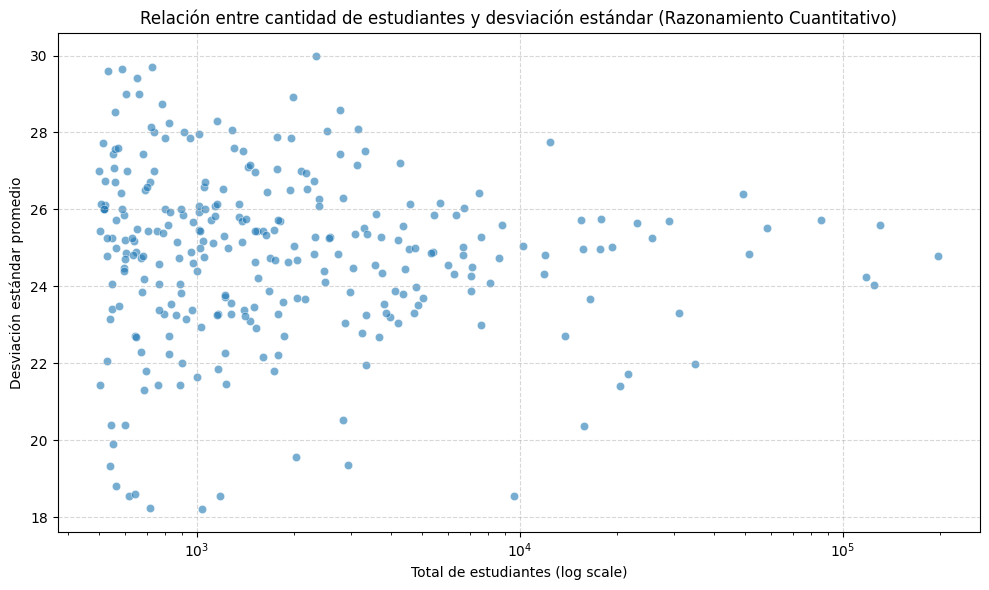

In [11]:
# Visualización 1 (gráfico de dispersión)
# Desviación estándar del puntaje de prueba en razonamiento cuantitativo
conn = sqlite3.connect('saberpro_star_schema.db')
query_corr = """
    SELECT 
        p.NOMBRE_PROGRAMA_ACAD,
        SUM(f.CANTIDADEVALUADOS) AS total_estudiantes,
        AVG(f.DESVIACION) AS desviacion_promedio
    FROM FACT_RESULTADOS f
    JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
    JOIN DIM_PRUEBA pr ON f.id_prueba = pr.id_prueba
    WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
      AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
      AND pr.NOMBRE_PRUEBA = 'RAZONAMIENTO CUANTITATIVO'
      AND f.DESVIACION IS NOT NULL
    GROUP BY p.NOMBRE_PROGRAMA_ACAD
    HAVING total_estudiantes >= 500;
"""
df_corr = pd.read_sql(query_corr, conn)
conn.close()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_corr, x='total_estudiantes', y='desviacion_promedio', alpha=0.6)
plt.title('Relación entre cantidad de estudiantes y desviación estándar (Razonamiento Cuantitativo)')
plt.xlabel('Total de estudiantes (log scale)')
plt.ylabel('Desviación estándar promedio')
plt.xscale('log')  # escala logarítmica por la amplia variación
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [2]:
# Exportar todas las tablas a archivos CSV (Para uso con Power BI o similares)
import sqlite3
import pandas as pd

db_path = r'C:\Users\NaujAlkml\Documents\IT-Stuff\Python_Jupyt-Colab_Prjcts\saberpro_star_schema.db'
conn = sqlite3.connect(db_path)

# Lista de tablas
tablas = ['DIM_GEOGRAFIA', 'DIM_INSTITUCION', 'DIM_PROGRAMA', 'DIM_PRUEBA', 'DIM_TIEMPO', 'FACT_RESULTADOS']

for nombre_tabla in tablas:
    # Leer tabla como un DataFrame de pandas
    df = pd.read_sql_query(f"SELECT * FROM {nombre_tabla}", conn)
    
    # Exportar a CSV en una carpeta: 'csv_exports'
    ruta_archivo = f'csv_exports/{nombre_tabla}.csv'
    df.to_csv(ruta_archivo, index=False, encoding='utf-8-sig')
    print(f"✅ Tabla '{nombre_tabla}' exportada exitosamente a '{ruta_archivo}'")

conn.close()
print("\n🎉 ¡Exportación completada!")

✅ Tabla 'DIM_GEOGRAFIA' exportada exitosamente a 'csv_exports/DIM_GEOGRAFIA.csv'
✅ Tabla 'DIM_INSTITUCION' exportada exitosamente a 'csv_exports/DIM_INSTITUCION.csv'
✅ Tabla 'DIM_PROGRAMA' exportada exitosamente a 'csv_exports/DIM_PROGRAMA.csv'
✅ Tabla 'DIM_PRUEBA' exportada exitosamente a 'csv_exports/DIM_PRUEBA.csv'
✅ Tabla 'DIM_TIEMPO' exportada exitosamente a 'csv_exports/DIM_TIEMPO.csv'
✅ Tabla 'FACT_RESULTADOS' exportada exitosamente a 'csv_exports/FACT_RESULTADOS.csv'

🎉 ¡Exportación completada!
